Modelo de regresión estimado:
nota = 2.24 + -0.03 * edad + 1.20 * horas_estudio


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


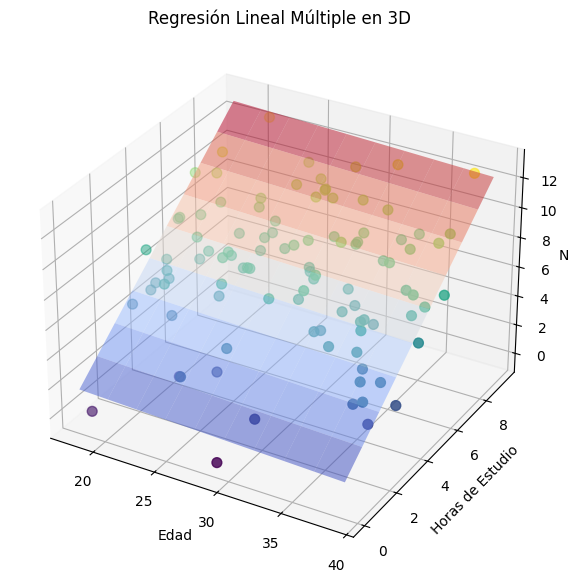

In [ ]:
# Paso 1: Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# Paso 2: Generar datos simulados
np.random.seed(42)
n = 100
edad = np.random.randint(18, 40, size=n)
horas_estudio = np.random.normal(5, 2, size=n).clip(0)  # >= 0
nota = 3 + (horas_estudio * 1.2) - (edad * 0.05) + np.random.normal(0, 1, size=n)

# Crear DataFrame
df = pd.DataFrame({
    'edad': edad,
    'horas_estudio': horas_estudio,
    'nota': nota
})

# Paso 3: Ajustar modelo de regresión lineal múltiple
X = df[['edad', 'horas_estudio']]
y = df['nota']
modelo = LinearRegression()
modelo.fit(X, y)
# Obtener intercepto y coeficientes
intercepto = modelo.intercept_
coef_edad = modelo.coef_[0]
coef_estudio = modelo.coef_[1]

# Imprimir la ecuación del modelo
print(f"Modelo de regresión estimado:")
print(f"nota = {intercepto:.2f} + {coef_edad:.2f} * edad + {coef_estudio:.2f} * horas_estudio")

# Paso 4: Crear malla para graficar el plano de predicción
edad_grid, estudio_grid = np.meshgrid(
    np.linspace(df['edad'].min(), df['edad'].max(), 10),
    np.linspace(df['horas_estudio'].min(), df['horas_estudio'].max(), 10)
)
X_pred = np.c_[edad_grid.ravel(), estudio_grid.ravel()]
y_pred = modelo.predict(X_pred).reshape(edad_grid.shape)

# Paso 5: Crear gráfico 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Puntos de datos reales
ax.scatter(df['edad'], df['horas_estudio'], df['nota'],
           c=df['nota'], cmap='viridis', s=50, label="Datos Reales")

# Plano del modelo de regresión
ax.plot_surface(edad_grid, estudio_grid, y_pred,
                cmap='coolwarm', alpha=0.5, label="Modelo")

# Etiquetas y título
ax.set_xlabel('Edad')
ax.set_ylabel('Horas de Estudio')
ax.set_zlabel('Nota')
ax.set_title('Regresión Lineal Múltiple en 3D')

plt.show()
# Este plano muestra cómo el modelo de regresión estima las notas según diferentes combinaciones de edad y horas de estudio:
# El plano se ajusta lo mejor posible a los puntos reales.
# Si los puntos están cerca del plano, significa que el modelo predice bien.
# Si los puntos están muy alejados del plano, hay errores de predicción.
# Interpretación del plano:
# A mayor cantidad de horas de estudio, la nota tiende a subir (el plano sube hacia el eje Y).
# A mayor edad, si el plano baja, significa que el modelo asocia edad con un leve descenso en nota, o que la edad tiene un
# impacto negativo (dependiendo del coeficiente estimado).



In [ ]:
# Paso 5: Predicción para un caso específico
edad_test = 25
horas_test = 6

nota_predicha = modelo.predict([[edad_test, horas_test]])
print(f"\nPredicción para edad = {edad_test} y horas_estudio = {horas_test}:")
print(f"nota esperada = {nota_predicha[0]:.2f}")


Predicción para edad = 25 y horas_estudio = 6:
nota esperada = 8.72


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


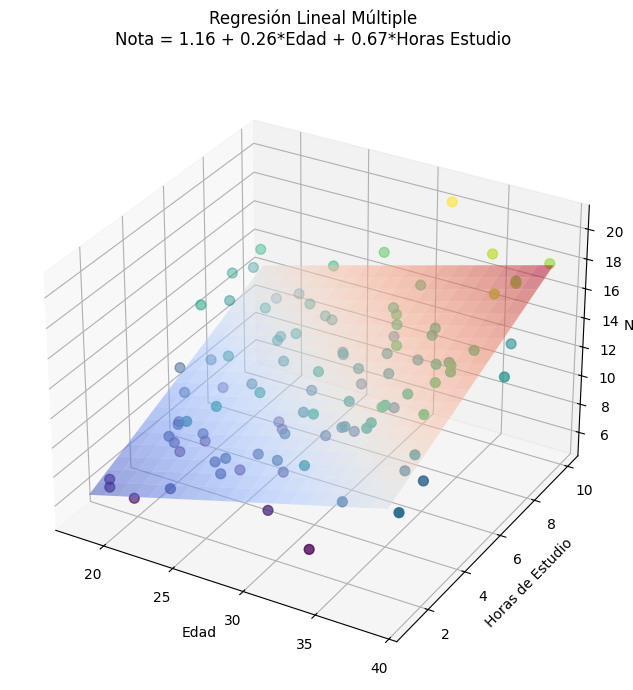

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# Paso 1: Generar datos de ejemplo
np.random.seed(42)
df = pd.DataFrame({
    'edad': np.random.randint(18, 40, size=100),
    'horas_estudio': np.random.uniform(1, 10, size=100)
})
df['nota'] = 0.3 * df['edad'] + 0.7 * df['horas_estudio'] + np.random.normal(0, 2, size=100)

# Paso 2: Ajustar modelo de regresión lineal múltiple
X = df[['edad', 'horas_estudio']]
y = df['nota']
modelo = LinearRegression()
modelo.fit(X, y)

# Coeficientes del modelo
intercepto = modelo.intercept_
coef_edad = modelo.coef_[0]
coef_horas = modelo.coef_[1]

# Paso 3: Crear malla para plano de regresión
edad_range = np.linspace(df['edad'].min(), df['edad'].max(), 20)
horas_range = np.linspace(df['horas_estudio'].min(), df['horas_estudio'].max(), 20)
edad_grid, horas_grid = np.meshgrid(edad_range, horas_range)
nota_grid = modelo.predict(np.c_[edad_grid.ravel(), horas_grid.ravel()]).reshape(edad_grid.shape)

# Paso 4: Crear gráfico 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Paso 5: Graficar puntos reales
sc = ax.scatter(df['edad'], df['horas_estudio'], df['nota'], c=df['nota'], cmap='viridis', s=50)

# Paso 6: Graficar plano de regresión
ax.plot_surface(edad_grid, horas_grid, nota_grid, alpha=0.5, cmap='coolwarm')

# Paso 7: Etiquetas de ejes
ax.set_xlabel('Edad')
ax.set_ylabel('Horas de Estudio')
ax.set_zlabel('Nota')

# Paso 8: Título con ecuación del modelo
equacion = f'Nota = {intercepto:.2f} + {coef_edad:.2f}*Edad + {coef_horas:.2f}*Horas Estudio'
plt.title(f'Regresión Lineal Múltiple\n{equacion}', pad=20)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


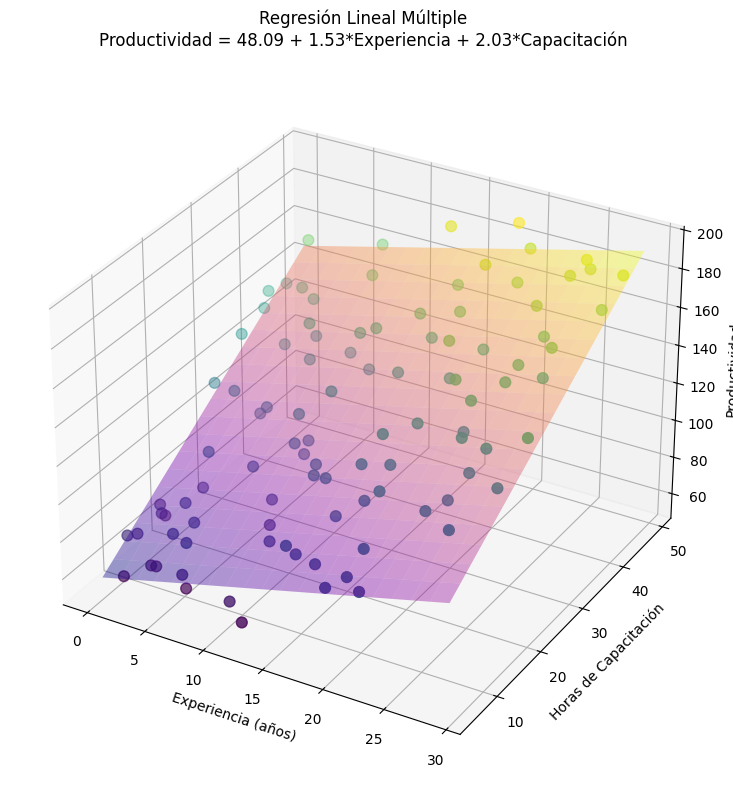

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# 1. Generar datos simulados
np.random.seed(0)
n = 100
experiencia = np.random.randint(0, 30, n)
horas_capacitacion = np.random.randint(5, 50, n)
productividad = 50 + 1.5 * experiencia + 2.0 * horas_capacitacion + np.random.normal(0, 10, n)

# 2. Crear DataFrame
df = pd.DataFrame({
    'experiencia': experiencia,
    'horas_capacitacion': horas_capacitacion,
    'productividad': productividad
})

# 3. Ajustar modelo de regresión lineal múltiple
X = df[['experiencia', 'horas_capacitacion']]
y = df['productividad']
modelo = LinearRegression()
modelo.fit(X, y)

# 4. Extraer coeficientes
intercepto = modelo.intercept_
coef_exp = modelo.coef_[0]
coef_cap = modelo.coef_[1]

# 5. Crear malla de valores para plano
exp_range = np.linspace(df['experiencia'].min(), df['experiencia'].max(), 20)
cap_range = np.linspace(df['horas_capacitacion'].min(), df['horas_capacitacion'].max(), 20)
exp_grid, cap_grid = np.meshgrid(exp_range, cap_range)
prod_grid = modelo.predict(np.c_[exp_grid.ravel(), cap_grid.ravel()]).reshape(exp_grid.shape)

# 6. Gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['experiencia'], df['horas_capacitacion'], df['productividad'],
           c=df['productividad'], cmap='viridis', s=60)
ax.plot_surface(exp_grid, cap_grid, prod_grid, alpha=0.4, cmap='plasma')

# 7. Etiquetas
ax.set_xlabel('Experiencia (años)')
ax.set_ylabel('Horas de Capacitación')
ax.set_zlabel('Productividad')

# 8. Mostrar ecuación en el título
ecuacion = f'Productividad = {intercepto:.2f} + {coef_exp:.2f}*Experiencia + {coef_cap:.2f}*Capacitación'
plt.title(f'Regresión Lineal Múltiple\n{ecuacion}', pad=20)

plt.tight_layout()
plt.show()